# Week 3: Model Creation and Evaluation

This notebook covers the task for Week 3 of the Machine Learning Project.

**Tasks:**
- Load the cleaned dataset
- Split Data (Train/Test)
- Train Model (Random Forest Classifier)
- Evaluate Model (Accuracy, Classification Report, Confusion Matrix)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## 1. Load Cleaned Data

In [4]:
input_file = "cardio_train_cleaned.csv"
print(f"Loading cleaned data from {input_file}...")
df = pd.read_csv(input_file)
df.head()

Loading cleaned data from cardio_train_cleaned.csv...


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.967120
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.927679
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.507805
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.710479
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.011177


## 2. Prepare Data (Features & Target, Split, Scale)

In [7]:
# Features and Target
X = df.drop('cardio',''. axis=1)
y = df['cardio']

# Split
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Splitting data...


In [9]:
X

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi
0,18393,2,168,62.0,110,80,1,1,0,0,1,50.4,21.967120
1,20228,1,156,85.0,140,90,3,1,0,0,1,55.4,34.927679
2,18857,1,165,64.0,130,70,3,1,0,0,0,51.6,23.507805
3,17623,2,169,82.0,150,100,1,1,0,0,1,48.2,28.710479
4,17474,1,156,56.0,100,60,1,1,0,0,0,47.8,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68479,19240,2,168,76.0,120,80,1,1,1,0,1,52.7,26.927438
68480,22601,1,158,126.0,140,90,2,2,0,0,1,61.9,50.472681
68481,19066,2,183,105.0,180,90,3,1,0,1,0,52.2,31.353579
68482,22431,1,163,72.0,135,80,1,2,0,0,0,61.4,27.099251


## 3. Train Model (Random Forest)

In [7]:
print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

Training Random Forest Classifier...


RandomForestClassifier(random_state=42)

## 4. Evaluation

In [9]:
# Predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluation
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Model Performance:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

Model Performance:
Train Accuracy: 0.9998
Test Accuracy:  0.7237

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.74      0.73      6906
           1       0.73      0.71      0.72      6791

    accuracy                           0.72     13697
   macro avg       0.72      0.72      0.72     13697
weighted avg       0.72      0.72      0.72     13697




Confusion Matrix:


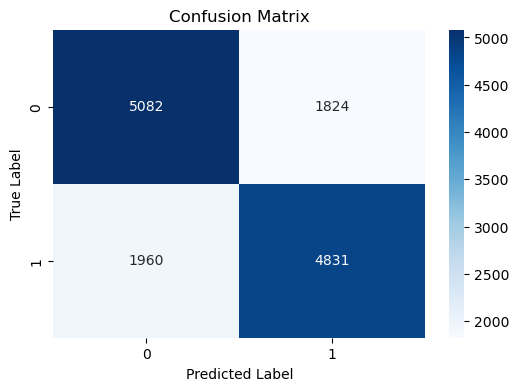

In [10]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. Save Model

In [12]:
# Save Model and Scaler
joblib.dump(model, 'cardio_model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved to cardio_model_rf.pkl")

Model saved to cardio_model_rf.pkl


In [13]:
## 6. Logistic Regre

In [14]:
# 3. Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Logistic Regression model...")

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

# 4. Predictions
y_pred = log_reg.predict(X_test_scaled)

# 5. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Logistic Regression model...
Accuracy: 0.7309629845951668

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6906
           1       0.76      0.68      0.71      6791

    accuracy                           0.73     13697
   macro avg       0.73      0.73      0.73     13697
weighted avg       0.73      0.73      0.73     13697


Confusion Matrix:
[[5426 1480]
 [2205 4586]]


In [15]:
# 4. Train Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Gradient Boosting Classifier model...")

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_scaled, y_train)


y_pred = gb_clf.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training Gradient Boosting Classifier model...
Accuracy: 0.7400160619113675

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6906
           1       0.76      0.70      0.73      6791

    accuracy                           0.74     13697
   macro avg       0.74      0.74      0.74     13697
weighted avg       0.74      0.74      0.74     13697


Confusion Matrix:
[[5398 1508]
 [2053 4738]]
